In [1]:
import pandas as pd
from pathlib import Path
import numpy as np

In [16]:
BASE = Path().resolve().parent
BASE

PosixPath('/Users/hengdegao/python')

In [17]:
RAW = BASE / 'thesis' / 'data' / 'original_data'
BLD = BASE/ 'thesis'/ 'data' / 'processed'
OUTPUT = BASE / 'thesis' / 'data' / 'outputs'

In [42]:
df_basic_file = RAW/'csmar'/'基本信息'/'上市公司基本信息年度表215937759'/'STK_LISTEDCOINFOANL.csv'
df_basic = pd.read_csv(df_basic_file, dtype={'Symbol': str})
df_basic = df_basic.fillna(0) 
df_basic["year"] = pd.to_datetime(df_basic["EndDate"]).dt.year.astype(int)
df_basic.rename(columns={'Symbol': 'Stkcd'}, inplace=True)
df_basic = df_basic[(df_basic['Stkcd'] >= "000001") & (df_basic['Stkcd'] <= "679999")]

df_basic

,Stkcd,ShortName,EndDate,IndustryCode,FullName,year
0,000001,平安银行,2012-12-31,J66,平安银行股份有限公司,2012
1,000001,平安银行,2013-12-31,J66,平安银行股份有限公司,2013
2,000001,平安银行,2014-12-31,J66,平安银行股份有限公司,2014
3,000001,平安银行,2015-12-31,J66,平安银行股份有限公司,2015
4,000001,平安银行,2016-12-31,J66,平安银行股份有限公司,2016
...,...,...,...,...,...,...
41815,605598,上海港湾,2022-12-31,E48,上海港湾基础建设(集团)股份有限公司,2022
41816,605598,上海港湾,2023-12-31,E48,上海港湾基础建设(集团)股份有限公司,2023
41817,605599,菜百股份,2021-12-31,F52,北京菜市口百货股份有限公司,2021
41818,605599,菜百股份,2022-12-31,F52,北京菜市口百货股份有限公司,2022


In [43]:
# 提取行业代码的大类（首字母）
df_basic['Industry_Main'] = df_basic['IndustryCode'].str[0]

# 找出每个公司在2014-2019年的唯一行业代码集合
industry_changes = df_basic[df_basic['year'].between(2014, 2019)].groupby('Stkcd')['Industry_Main'].apply(set)

# 筛选出行业代码集合长度大于1的公司，表示发生过行业代码变化
companies_with_changes = industry_changes[industry_changes.apply(len) > 1].index

df_basic = df_basic[~df_basic['Stkcd'].isin(companies_with_changes)]


In [40]:
df_basic

,Stkcd,ShortName,EndDate,IndustryCode,FullName,year,Industry_Main
0,000001,平安银行,2012-12-31,J66,平安银行股份有限公司,2012,J
1,000001,平安银行,2013-12-31,J66,平安银行股份有限公司,2013,J
2,000001,平安银行,2014-12-31,J66,平安银行股份有限公司,2014,J
3,000001,平安银行,2015-12-31,J66,平安银行股份有限公司,2015,J
4,000001,平安银行,2016-12-31,J66,平安银行股份有限公司,2016,J
...,...,...,...,...,...,...,...
41815,605598,上海港湾,2022-12-31,E48,上海港湾基础建设(集团)股份有限公司,2022,E
41816,605598,上海港湾,2023-12-31,E48,上海港湾基础建设(集团)股份有限公司,2023,E
41817,605599,菜百股份,2021-12-31,F52,北京菜市口百货股份有限公司,2021,F
41818,605599,菜百股份,2022-12-31,F52,北京菜市口百货股份有限公司,2022,F


In [353]:
df_basic[df_basic['Stkcd'] == '000595']

,Stkcd,ShortName,EndDate,IndustryCode,FullName,year,Industry_Main
2073,000595,*ST 西轴,2012-12-31,C34,西北轴承股份有限公司,2012,C
2074,000595,西北轴承,2013-12-31,C34,西北轴承股份有限公司,2013,C
2075,000595,西北轴承,2014-12-31,C34,西北轴承股份有限公司,2014,C
2076,000595,宝塔实业,2015-12-31,C34,宝塔实业股份有限公司,2015,C
2077,000595,宝塔实业,2016-12-31,C34,宝塔实业股份有限公司,2016,C
2078,000595,*ST 宝实,2017-12-31,C34,宝塔实业股份有限公司,2017,C
2079,000595,宝塔实业,2018-12-31,C34,宝塔实业股份有限公司,2018,C
2080,000595,宝塔实业,2019-12-31,C34,宝塔实业股份有限公司,2019,C
2081,000595,*ST 宝实,2020-12-31,C34,宝塔实业股份有限公司,2020,C
2082,000595,宝塔实业,2021-12-31,C34,宝塔实业股份有限公司,2021,C


In [354]:
df_basic[df_basic['ShortName'].str.contains('ST', case=False, na=False)]


,Stkcd,ShortName,EndDate,IndustryCode,FullName,year,Industry_Main
155,000017,*ST 中华A,2012-12-31,C37,深圳中华自行车(集团)股份有限公司,2012,C
156,000017,*ST 中华A,2013-12-31,C37,深圳中华自行车(集团)股份有限公司,2013,C
163,000017,*ST 中华A,2020-12-31,C37,深圳中华自行车(集团)股份有限公司,2020,C
227,000023,ST 深天,2023-12-31,C30,深圳市天地(集团)股份有限公司,2023,C
291,000030,*ST 盛润A,2012-12-31,C41,广东盛润集团股份有限公司,2012,C
...,...,...,...,...,...,...,...
40473,603779,ST 威龙,2020-12-31,C15,威龙葡萄酒股份有限公司,2020,C
40781,603863,ST 松炀,2021-12-31,C22,广东松炀再生资源股份有限公司,2021,C
40857,603880,ST 南卫,2023-12-31,C27,江苏南方卫材医药股份有限公司,2023,C
41376,603996,*ST 中新,2020-12-31,C39,中新科技集团股份有限公司,2020,C


In [21]:
df_subsidiary_file = RAW/'csmar'/'基本信息'/'上市公司子公司情况表220415924'/'FN_Fn061.csv'
df_subsidiary = pd.read_csv(df_subsidiary_file, dtype={'Stkcd': str})
df_subsidiary["year"] = pd.to_datetime(df_subsidiary["EndDate"]).dt.year.astype(int)
df_subsidiary = df_subsidiary[(df_subsidiary['Stkcd'] >= "000001") & (df_subsidiary['Stkcd'] <= "679999")]

df_subsidiary = df_subsidiary[~df_subsidiary['Stkcd'].isin(companies_with_changes)]
df_subsidiary

,Stkcd,EndDate,FN_Fn06101,year
0,000001,2012-12-31,平安银行股份有限公司,2012
1,000002,2012-12-31,万科(重庆)房地产有限公司,2012
2,000002,2012-12-31,万科中粮(苏州)置业有限公司,2012
3,000002,2012-12-31,万科地产(香港)有限公司,2012
4,000002,2012-12-31,万科物业发展有限公司,2012
...,...,...,...,...
220389,603999,2016-12-31,甘肃人民美术出版社有限责任公司,2016
220390,603999,2016-12-31,甘肃民族出版社有限责任公司,2016
220391,603999,2016-12-31,敦煌文艺出版社有限责任公司,2016
220392,603999,2016-12-31,北京读者天元文化传播有限公司,2016


In [11]:
df_basic['company'] = df_basic['FullName']  # 母公司名称列
df_subsidiary['company'] = df_subsidiary['FN_Fn06101']
merged_df_list = pd.concat(
    [
        df_basic[['Stkcd', 'year', 'company']], 
        df_subsidiary[['Stkcd', 'year', 'company']],
    ],
    axis=0,
    ignore_index=True
)
merged_df_list.sort_values(by=['Stkcd', 'year'], inplace=True)


/var/folders/c4/jcwfyw7s1xscfrfpb3gm8bn40000gn/T/ipykernel_65168/3953326963.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_basic['company'] = df_basic['FullName']  # 母公司名称列


In [356]:
df_export_file = RAW / 'cn_custom_data'/'2014_2016_export_data.parquet'
df_export = pd.read_parquet(df_export_file)

In [357]:
df_export.shape

(37512393, 6)

In [359]:
result_df = pd.merge(
    merged_df_list,  # 包含母公司和子公司名称的表
    df_export[['Company_Name', 'Year', 'Country_Name', 'Export_Amount', 'Product_Code']],
    left_on=['company', 'year'],
    right_on=['Company_Name', 'Year'],
    how='inner'
)
result_df['hs_code'] = result_df['Product_Code'].astype(str).str[:6].astype(int)

result_df

,Stkcd,year,company,Company_Name,Year,Country_Name,Export_Amount,Product_Code,hs_code
0,000009,2014,江西宝安新材料科技有限公司,江西宝安新材料科技有限公司,2014,美国,58589.0,69091200,690912
1,000009,2014,江西宝安新材料科技有限公司,江西宝安新材料科技有限公司,2014,荷兰,60659.0,69091900,690919
2,000009,2014,江西宝安新材料科技有限公司,江西宝安新材料科技有限公司,2014,印度尼西亚,1378.0,28182000,281820
3,000009,2014,江西宝安新材料科技有限公司,江西宝安新材料科技有限公司,2014,美国,290914.0,69091900,690919
4,000009,2014,江西宝安新材料科技有限公司,江西宝安新材料科技有限公司,2014,马来西亚,3018.0,69091900,690919
...,...,...,...,...,...,...,...,...,...
1082742,603999,2016,读者甘肃数码科技有限公司,读者甘肃数码科技有限公司,2016,香港,1010.0,39269090,392690
1082743,603999,2016,读者甘肃数码科技有限公司,读者甘肃数码科技有限公司,2016,香港,1738703.0,84713010,847130
1082744,603999,2016,读者甘肃数码科技有限公司,读者甘肃数码科技有限公司,2016,突尼斯,67200.0,84713010,847130
1082745,603999,2016,读者甘肃数码科技有限公司,读者甘肃数码科技有限公司,2016,法国,25200.0,84713010,847130


In [295]:
# 筛选出出口美国的数据
df_usa = result_df[result_df['Country_Name'] == '美国']
exchange_rates = {2014: 6.128333, 2015: 6.205000, 2016: 6.614167}
df_usa = df_usa.copy()

# 计算转换后的金额
df_usa['export'] = df_usa.apply(lambda row: row['Export_Amount'] * exchange_rates[row['year']], axis=1)

# 按HS代码、公司代码、年份分类
grouped_df = df_usa.groupby(['Stkcd', 'year', 'hs_code'], as_index=False).agg({
    'Export_Amount': 'sum',  # 汇总出口金额
    'export': 'sum'  # 汇总转换后的金额
})

# 按公司代码（Stkcd）和年份（year）排序
df_usa = grouped_df.sort_values(by=['Stkcd', 'year']).reset_index(drop=True)

df_usa


,Stkcd,year,hs_code,Export_Amount,export
0,000009,2014,690911,73101.0,4.479873e+05
1,000009,2014,690912,58589.0,3.590529e+05
2,000009,2014,690919,290914.0,1.782818e+06
3,000009,2015,250410,16967.0,1.052802e+05
4,000009,2015,380110,2271400.0,1.409404e+07
...,...,...,...,...,...
44497,603997,2014,940190,421150.0,2.580947e+06
44498,603997,2015,940190,590145.0,3.661850e+06
44499,603997,2016,731814,3.0,1.984250e+01
44500,603997,2016,940190,3179278.0,2.102828e+07


In [296]:
# 筛选出至少有2年数据的公司代码
company_year_counts = df_usa.groupby('Stkcd')['year'].nunique()
valid_companies = company_year_counts[company_year_counts >= 2].index

# 筛选出这些公司代码对应的行
df_usa = df_usa[df_usa['Stkcd'].isin(valid_companies)]
df_usa

,Stkcd,year,hs_code,Export_Amount,export
0,000009,2014,690911,73101.0,4.479873e+05
1,000009,2014,690912,58589.0,3.590529e+05
2,000009,2014,690919,290914.0,1.782818e+06
3,000009,2015,250410,16967.0,1.052802e+05
4,000009,2015,380110,2271400.0,1.409404e+07
...,...,...,...,...,...
44497,603997,2014,940190,421150.0,2.580947e+06
44498,603997,2015,940190,590145.0,3.661850e+06
44499,603997,2016,731814,3.0,1.984250e+01
44500,603997,2016,940190,3179278.0,2.102828e+07


In [284]:
single_year_companies = company_year_counts[company_year_counts == 1].index

# 筛选出这些公司代码对应的行
df_usa[df_usa['Stkcd'].isin(single_year_companies)]

,Stkcd,year,hs_code,Export_Amount,export
29,000011,2014,330290,39000.0,2.390050e+05
30,000011,2014,950300,241548.0,1.480287e+06
614,000065,2016,392690,214762.0,1.420472e+06
615,000065,2016,460290,150.0,9.921250e+02
616,000065,2016,481910,6440.0,4.259524e+04
...,...,...,...,...,...
44474,603987,2016,901890,19000.0,1.256692e+05
44475,603987,2016,980400,98.0,6.481884e+02
44476,603988,2016,848360,2030.0,1.342676e+04
44477,603988,2016,850153,38171.0,2.524694e+05


In [351]:
df_usa[df_usa['Stkcd'] == '000065']

,Stkcd,year,hs_code,Export_Amount,export


In [298]:
# 计算2014-2016年的公司-商品组合的平均出口金额
df_usa_avg = df_usa.groupby(['Stkcd', 'hs_code'])['export'].mean().reset_index()

# 重命名列
df_usa_avg.rename(columns={'export': 'avg_export_amount'}, inplace=True)
df_usa_avg['hs_code'] = df_usa_avg['hs_code'].astype(int)

df_usa_avg

,Stkcd,hs_code,avg_export_amount
0,000009,250410,3.045076e+05
1,000009,284290,2.976375e+03
2,000009,380110,2.327422e+07
3,000009,381590,3.442277e+05
4,000009,392350,1.448503e+04
...,...,...,...
24326,603997,392690,1.804181e+04
24327,603997,600632,1.218006e+05
24328,603997,731814,2.830625e+01
24329,603997,940190,9.090358e+06


In [79]:
import pdfplumber
import re

pdf_path = RAW/'us_tariff'/'FRN301.pdf'
all_text = ""
with pdfplumber.open(pdf_path) as pdf:
    for page in pdf.pages:
        all_text += page.extract_text() + " "

# Continue with your regex extraction as before
hts_codes = re.findall(r'\b\d{8}\b', all_text)
hts_prefixes = {code[:6] for code in hts_codes}

hts_list_1 = sorted(hts_prefixes)
print (hts_list_1)


['100084', '100086', '100187', '100841', '100842', '100845', '101844', '101845', '101918', '108429', '108439', '108458', '108528', '108607', '121408', '121808', '122408', '122808', '124018', '128018', '130901', '140118', '150844', '160901', '170845', '180118', '181408', '181808', '182408', '182808', '184223', '184224', '184229', '190845', '190901', '191908', '199108', '199908', '284430', '284590', '291462', '291469', '291899', '292146', '292149', '292219', '292250', '292429', '292800', '293190', '293299', '293339', '293399', '293499', '293711', '293719', '293723', '293750', '293790', '300120', '300211', '300212', '300213', '300214', '300215', '300219', '300220', '300230', '300290', '300320', '300331', '300339', '300341', '300342', '300343', '300349', '300360', '300390', '300410', '300420', '300431', '300432', '300439', '300441', '300442', '300443', '300449', '300450', '300460', '300490', '300510', '300610', '300620', '300630', '300640', '300660', '300670', '300691', '382000', '400610',

In [73]:
# 文件路径
pdf_path = RAW/'us_tariff'/'list_2.pdf'  # 替换为您的PDF路径

all_text = ""
with pdfplumber.open(pdf_path) as pdf:
    for page_number in range(4, 9):  # 页码从 0 开始，第 5 页是索引 4
        page = pdf.pages[page_number]
        all_text += page.extract_text() + " "

# 使用正则表达式提取8位 HTSUS 代码

hts_codes = re.findall(r'\b\d{4}\.\d{2}\.\d{2}\b', all_text)

# 格式化为6位代码（去掉圆点和后两位）
hts_prefixes = {code.replace(".", "")[:6] for code in hts_codes}

# 排序结果
hts_list_2 = sorted(hts_prefixes)
print (hts_list_2)


['284590', '401130', '401213', '840110', '840120', '840130', '840140', '840211', '840212', '840219', '840220', '840290', '840420', '840490', '840510', '840590', '840610', '840681', '840682', '840710', '840721', '840729', '840810', '840890', '840910', '841011', '841012', '841013', '841090', '841111', '841112', '841121', '841122', '841181', '841182', '841191', '841199', '841210', '841221', '841229', '841231', '841239', '841280', '841290', '841319', '841340', '841350', '841360', '841370', '841381', '841382', '841391', '841430', '841459', '841480', '841490', '841690', '841710', '841780', '841790', '841869', '841911', '841919', '841931', '841932', '841939', '841940', '841950', '841960', '841989', '841990', '842010', '842091', '842099', '842119', '842121', '842122', '842129', '842139', '842191', '842199', '842219', '842220', '842230', '842240', '842290', '842320', '842330', '842382', '842389', '842390', '842489', '842490', '842511', '842539', '842641', '842649', '842699', '842710', '842720',

In [76]:
# 文件路径
pdf_path = RAW/'us_tariff'/'list_3.pdf'  # 替换为您的PDF路径

# 合并所有页面的文本
all_text = ""
with pdfplumber.open(pdf_path) as pdf:
    for page_number in range(3, 28): 
        page = pdf.pages[page_number]
        all_text += page.extract_text() + " "

# 使用正则提取所有符合8位格式的代码
hts_codes = re.findall(r'\b\d{4}\.\d{2}\.\d{2}\b', all_text)

# 格式化为6位代码（去掉圆点和后两位）
hts_prefixes = {code.replace(".", "")[:6] for code in hts_codes}

# 排序结果
hts_list_3 = sorted(hts_prefixes)
print (hts_list_3)

['020329', '020610', '020810', '020890', '021019', '030111', '030119', '030191', '030192', '030193', '030194', '030195', '030199', '030211', '030213', '030214', '030219', '030221', '030222', '030223', '030224', '030229', '030231', '030232', '030233', '030234', '030235', '030236', '030239', '030241', '030242', '030243', '030244', '030245', '030246', '030247', '030249', '030251', '030252', '030253', '030254', '030255', '030256', '030259', '030271', '030272', '030273', '030274', '030279', '030281', '030282', '030283', '030284', '030285', '030289', '030291', '030292', '030299', '030311', '030312', '030313', '030314', '030319', '030323', '030324', '030325', '030326', '030329', '030331', '030332', '030333', '030334', '030339', '030341', '030342', '030343', '030344', '030345', '030346', '030349', '030351', '030353', '030354', '030355', '030356', '030357', '030359', '030363', '030364', '030365', '030366', '030367', '030368', '030381', '030382', '030383', '030384', '030389', '030391', '030392',

In [77]:
# 文件路径
pdf_path = RAW/'us_tariff'/'list_4.pdf'  # 替换为您的PDF路径

# 合并所有页面的文本
all_text = ""
with pdfplumber.open(pdf_path) as pdf:
    for page_number in range(3, 25): 
        page = pdf.pages[page_number]
        all_text += page.extract_text() + " "

# 使用正则提取所有符合8位格式的代码
hts_codes = re.findall(r'\b\d{4}\.\d{2}\.\d{2}\b', all_text)

# 格式化为6位代码（去掉圆点和后两位）
hts_prefixes = {code.replace(".", "")[:6] for code in hts_codes}

# 排序结果
hts_list_4 = sorted(hts_prefixes)
print (hts_list_4)

['010121', '010129', '010130', '010190', '010221', '010229', '010231', '010239', '010290', '010310', '010391', '010392', '010410', '010420', '010511', '010512', '010513', '010514', '010515', '010594', '010599', '010611', '010612', '010613', '010614', '010619', '010620', '010631', '010632', '010633', '010639', '010641', '010649', '010690', '020110', '020120', '020130', '020210', '020220', '020230', '020311', '020312', '020319', '020321', '020322', '020410', '020421', '020422', '020423', '020430', '020441', '020442', '020443', '020450', '020500', '020621', '020622', '020629', '020630', '020641', '020649', '020680', '020690', '020711', '020712', '020713', '020714', '020724', '020725', '020726', '020727', '020741', '020742', '020743', '020744', '020745', '020751', '020752', '020753', '020754', '020755', '020760', '020830', '020840', '020850', '020860', '020890', '020910', '020990', '021011', '021012', '021020', '021091', '021092', '021093', '021099', '040110', '040120', '040140', '040150',

In [80]:
set1 = set(hts_list_1)
set2 = set(hts_list_2)
set3 = set(hts_list_3)
set4 = set(hts_list_4)

In [81]:
set5 = set1 | set2 | set3 
 

In [84]:
print(set5 & set4)

{'722300', '200899', '071334', '845221', '930400', '842290', '844391', '846719', '292142', '722699', '293090', '844511', '842490', '270799', '844590', '190190', '380861', '730511', '902620', '840310', '871130', '845290', '841590', '720720', '900791', '847810', '852380', '844832', '170490', '901390', '521011', '721430', '722020', '720837', '730429', '080310', '847979', '382000', '760611', '401219', '844530', '722219', '844833', '590310', '291634', '071190', '721911', '852871', '721310', '843410', '721114', '844720', '760421', '722211', '760519', '200570', '721631', '760120', '400912', '845229', '120230', '844849', '852580', '902990', '730419', '844519', '071080', '848190', '200949', '200830', '220299', '071410', '940190', '721220', '722240', '720719', '843020', '844319', '720852', '200791', '200799', '844842', '070890', '292145', '140490', '848060', '721399', '844339', '281119', '071159', '842810', '844851', '844090', '170290', '722692', '722220', '292690', '721240', '721190', '721610',

In [88]:
set6 = (set4 - set5)

In [90]:
set6 & set5

set()

In [102]:
hts_list_1_3 = sorted([int(item) for item in set5])


In [103]:
hts_list_4 = sorted([int(item) for item in set6])

In [290]:
df_usa['Stkcd'].nunique()

997

In [291]:
df_usa_avg['Stkcd'].nunique()

997

In [294]:
df_usa_avg

Stkcd                 object
hs_code               object
avg_export_amount    float64
dtype: object

In [299]:
df_usa_avg['affected_1_3'] = df_usa_avg['hs_code'].isin(hts_list_1_3)
df_usa_avg['affected_4'] = df_usa_avg['hs_code'].isin(hts_list_4)

# 按公司代码计算总金额
df_total = df_usa_avg.groupby('Stkcd')['avg_export_amount'].sum().reset_index()
df_total.rename(columns={'avg_export_amount': 'total_export_amount'}, inplace=True)

# 按公司代码计算受影响金额
df_1_3 = df_usa_avg[df_usa_avg['affected_1_3']].groupby('Stkcd')['avg_export_amount'].sum().reset_index()
df_1_3.rename(columns={'avg_export_amount': 'amount_affected_1_3'}, inplace=True)

df_4 = df_usa_avg[df_usa_avg['affected_4']].groupby('Stkcd')['avg_export_amount'].sum().reset_index()
df_4.rename(columns={'avg_export_amount': 'amount_affected_4'}, inplace=True)

# 合并结果
result = pd.merge(df_total, df_1_3, on='Stkcd', how='left')
result = pd.merge(result, df_4, on='Stkcd', how='left')

result.fillna(0, inplace=True)

# 计算受影响百分比
#result['affected_percentage_1_3'] = result['amount_affected_1_3'] / result['total_export_amount'] 
#result['affected_percentage_4'] = result['amount_affected_4'] / result['total_export_amount'] 


result

,Stkcd,total_export_amount,amount_affected_1_3,amount_affected_4
0,000009,3.130058e+07,3.099408e+07,0.000000e+00
1,000012,8.859766e+06,8.859766e+06,0.000000e+00
2,000016,8.749128e+08,8.027679e+08,5.054625e+05
3,000020,5.433077e+06,9.845915e+05,0.000000e+00
4,000021,1.762177e+08,9.331029e+07,8.093301e+07
...,...,...,...,...
992,603968,1.824172e+08,1.815179e+08,0.000000e+00
993,603969,7.636192e+06,7.636192e+06,0.000000e+00
994,603989,6.877404e+06,6.877404e+06,0.000000e+00
995,603996,7.367749e+08,6.859205e+08,3.629002e+06


In [134]:
# Define conditions for classification
conditions = [
    (result['affected_percentage_1_3'] > 0.30) & (result['affected_percentage_4'] < 0.30),  # Condition 1
    (result['affected_percentage_1_3'] <= 0.30) & (result['affected_percentage_4'] <= 0.30),  # Condition 2
    (result['affected_percentage_1_3'] < 0.30) & (result['affected_percentage_4'] > 0.30),  # Condition 3
    (result['affected_percentage_1_3'] > 0.30) & (result['affected_percentage_4'] > 0.30)  # Condition 4
]

# Assign values based on conditions
result['category'] = 0  # Initialize with default value
result.loc[conditions[0], 'category'] = 1
result.loc[conditions[1], 'category'] = 2
result.loc[conditions[2], 'category'] = 3
result.loc[conditions[3], 'category'] = 4
result

,Stkcd,total_export_amount,amount_affected_1_3,amount_affected_4,affected_percentage_1_3,affected_percentage_4,category
0,000009,4.824842e+06,4.777976e+06,0.000000,0.990287,0.000000,1
1,000011,2.805480e+05,3.900000e+04,0.000000,0.139014,0.000000,2
2,000012,1.388617e+06,1.388617e+06,0.000000,1.000000,0.000000,1
3,000016,1.373664e+08,1.257301e+08,78110.166667,0.915289,0.000569,1
4,000020,8.513725e+05,1.488610e+05,0.000000,0.174848,0.000000,2
...,...,...,...,...,...,...,...
1369,603987,1.554768e+07,1.554758e+07,0.000000,0.999994,0.000000,1
1370,603988,1.150340e+05,1.150340e+05,0.000000,1.000000,0.000000,1
1371,603989,1.070583e+06,1.070583e+06,0.000000,1.000000,0.000000,1
1372,603996,1.114240e+08,1.037047e+08,579205.000000,0.930722,0.005198,1


In [140]:
result['category'].value_counts()

category
1    1021
2     159
3     137
4      57
Name: count, dtype: int64

In [131]:
result.describe(include='all').transpose()


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Stkcd,1374,1374,000009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_export_amount,1374.0,NaN,NaN,NaN,20766055.902475,81513932.463154,5.0,215105.666667,1907035.166667,12279514.0,1445683775.833333
amount_affected_1_3,1374.0,NaN,NaN,NaN,12094390.070233,40590337.585028,0.0,75008.75,958865.333333,7201219.666667,844888859.5
amount_affected_4,1374.0,NaN,NaN,NaN,3884427.537482,28848235.648678,0.0,0.0,0.0,19967.0,820208824.5
affected_percentage_1_3,1374.0,NaN,NaN,NaN,0.73399,0.385161,0.0,0.459872,0.99505,1.0,1.0
affected_percentage_4,1374.0,NaN,NaN,NaN,0.11853,0.278385,0.0,0.0,0.0,0.00849,1.0


In [172]:
income_columns = {"Stkcd": "Stkcd","Accper": "year", "B001100000": "revenue"}
df_income_file = RAW/'csmar'/'基本信息'/'利润表000222262'/'FS_Comins.csv'
df_income = pd.read_csv(df_income_file, usecols=income_columns.keys(), dtype={'Stkcd': str}).rename(columns=income_columns)
df_income.loc[:, "year"] = pd.to_datetime(df_income["year"]).dt.year
df_income = df_income[(df_income['Stkcd'] >= "000001") & (df_income['Stkcd'] <= "679999")]
df_income

,Stkcd,year,revenue
0,000002,2013,1.354188e+11
1,000002,2014,1.463880e+11
2,000002,2015,1.955491e+11
3,000002,2016,2.404772e+11
4,000002,2017,2.428971e+11
...,...,...,...
36264,605598,2022,8.851052e+08
36265,605598,2023,1.277448e+09
36266,605599,2021,1.040575e+10
36267,605599,2022,1.098987e+10


In [173]:
df_income['Stkcd'].nunique()

4405

In [247]:
df_basic_file = RAW/'csmar'/'基本信息'/'上市公司基本信息年度表215937759'/'STK_LISTEDCOINFOANL.csv'
df_basic = pd.read_csv(df_basic_file, dtype={'Symbol': str})
df_basic = df_basic.fillna(0) 
df_basic["year"] = pd.to_datetime(df_basic["EndDate"]).dt.year.astype(int)
df_basic.rename(columns={'Symbol': 'Stkcd'}, inplace=True)
df_basic = df_basic[(df_basic['Stkcd'] >= "000001") & (df_basic['Stkcd'] <= "679999")]
# 提取行业代码的大类（首字母）
df_basic['Industry_Main'] = df_basic['IndustryCode'].str[0]

# 找出每个公司在2014-2019年的唯一行业代码集合
industry_changes = df_basic[df_basic['year'].between(2014, 2019)].groupby('Stkcd')['Industry_Main'].apply(set)

# 筛选出行业代码集合长度大于1的公司，表示发生过行业代码变化
companies_with_changes = industry_changes[industry_changes.apply(len) > 1].index
df_basic = df_basic[~df_basic['Stkcd'].isin(companies_with_changes)]

df_basic

,Stkcd,ShortName,EndDate,IndustryCode,FullName,year,Industry_Main
0,000001,平安银行,2012-12-31,J66,平安银行股份有限公司,2012,J
1,000001,平安银行,2013-12-31,J66,平安银行股份有限公司,2013,J
2,000001,平安银行,2014-12-31,J66,平安银行股份有限公司,2014,J
3,000001,平安银行,2015-12-31,J66,平安银行股份有限公司,2015,J
4,000001,平安银行,2016-12-31,J66,平安银行股份有限公司,2016,J
...,...,...,...,...,...,...,...
41815,605598,上海港湾,2022-12-31,E48,上海港湾基础建设(集团)股份有限公司,2022,E
41816,605598,上海港湾,2023-12-31,E48,上海港湾基础建设(集团)股份有限公司,2023,E
41817,605599,菜百股份,2021-12-31,F52,北京菜市口百货股份有限公司,2021,F
41818,605599,菜百股份,2022-12-31,F52,北京菜市口百货股份有限公司,2022,F


In [251]:
df_basic[df_basic['Stkcd']=='603997']

,Stkcd,ShortName,EndDate,IndustryCode,FullName,year,Industry_Main
41378,603997,继峰股份,2014-12-31,C36,宁波继峰汽车零部件股份有限公司,2014,C
41379,603997,继峰股份,2015-12-31,C36,宁波继峰汽车零部件股份有限公司,2015,C
41380,603997,继峰股份,2016-12-31,C36,宁波继峰汽车零部件股份有限公司,2016,C
41381,603997,继峰股份,2017-12-31,C36,宁波继峰汽车零部件股份有限公司,2017,C
41382,603997,继峰股份,2018-12-31,C36,宁波继峰汽车零部件股份有限公司,2018,C
41383,603997,继峰股份,2019-12-31,C36,宁波继峰汽车零部件股份有限公司,2019,C
41384,603997,继峰股份,2020-12-31,C36,宁波继峰汽车零部件股份有限公司,2020,C
41385,603997,继峰股份,2021-12-31,C36,宁波继峰汽车零部件股份有限公司,2021,C
41386,603997,继峰股份,2022-12-31,C36,宁波继峰汽车零部件股份有限公司,2022,C
41387,603997,继峰股份,2023-12-31,C36,宁波继峰汽车零部件股份有限公司,2023,C


In [252]:
df_income[df_income['Stkcd']=='603997']

,Stkcd,year,revenue
35827,603997,2014,1.017917e+09
35828,603997,2015,1.048068e+09
35829,603997,2016,1.465508e+09
35830,603997,2017,1.902072e+09
35831,603997,2018,2.151347e+09
35832,603997,2019,1.800126e+10
35833,603997,2020,1.573275e+10
35834,603997,2021,1.683199e+10
35835,603997,2022,1.796680e+10
35836,603997,2023,2.157149e+10


In [248]:
merged_df = pd.merge(df_income, df_basic[['Stkcd', 'year', 'Industry_Main']], on=['Stkcd', 'year'], how='left')

# 重命名列
merged_df.rename(columns={"Industry_Main": "industry"}, inplace=True)
merged_df = merged_df.dropna()
########################################################记得改时间
complete_years = set(range(2013, 2024)) 
company_year_counts = merged_df.groupby("Stkcd")["year"].apply(set)
valid_companies = company_year_counts[company_year_counts.apply(lambda x: complete_years.issubset(x))].index
merged_df = merged_df[merged_df["Stkcd"].isin(valid_companies)]
merged_df = merged_df[merged_df['year'] != 2013]
merged_df

,Stkcd,year,revenue,industry
1,000002,2014,1.463880e+11,K
2,000002,2015,1.955491e+11,K
3,000002,2016,2.404772e+11,K
4,000002,2017,2.428971e+11,K
5,000002,2018,2.976793e+11,K
...,...,...,...,...
35810,603993,2019,6.867657e+10,B
35811,603993,2020,1.129810e+11,B
35812,603993,2021,1.738626e+11,B
35813,603993,2022,1.729909e+11,B


In [187]:
merged_df.isna().sum()

Stkcd       0
year        0
revenue     0
industry    0
dtype: int64

In [250]:
average_revenue_df = (
    merged_df[(merged_df['year'] >= 2014) & (merged_df['year'] <= 2016)]
    .groupby('Stkcd')['revenue']
    .mean()
    .reset_index()
    .rename(columns={'revenue': 'average_revenue'})
)
average_revenue_df

,Stkcd,average_revenue
0,000002,1.941381e+11
1,000006,3.113955e+09
2,000009,5.218518e+09
3,000011,1.468358e+09
4,000012,7.816492e+09
...,...,...
1972,603366,2.665617e+09
1973,603399,1.757325e+09
1974,603699,2.309872e+09
1975,603766,7.389930e+09


In [301]:
merged_df = pd.merge(average_revenue_df, result, on='Stkcd', how='left').fillna(0)
# 计算比例
merged_df['ratio_affected_1_3'] = merged_df['amount_affected_1_3'] / merged_df['average_revenue']
merged_df['ratio_affected_4'] = merged_df['amount_affected_4'] / merged_df['average_revenue']


merged_df


,Stkcd,average_revenue,total_export_amount,amount_affected_1_3,amount_affected_4,ratio_affected_1_3,ratio_affected_4
0,000002,1.941381e+11,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000
1,000006,3.113955e+09,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000
2,000009,5.218518e+09,3.130058e+07,3.099408e+07,0.000000,0.005939,0.000000
3,000011,1.468358e+09,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000
4,000012,7.816492e+09,8.859766e+06,8.859766e+06,0.000000,0.001133,0.000000
...,...,...,...,...,...,...,...
1972,603366,2.665617e+09,1.585119e+06,1.585119e+06,0.000000,0.000595,0.000000
1973,603399,1.757325e+09,1.401381e+07,0.000000e+00,0.000000,0.000000,0.000000
1974,603699,2.309872e+09,2.450267e+08,2.450108e+08,7350.709075,0.106071,0.000003
1975,603766,7.389930e+09,7.388317e+08,3.608245e+08,37829.567500,0.048827,0.000005


In [302]:
merged_df.describe(include='all').transpose()


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Stkcd,1977,1977,000002,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
average_revenue,1977.0,NaN,NaN,NaN,11324437321.169752,76088373743.815689,13522574.876667,904028196.973333,2072497781.09,5714265190.0,2258569333333.333496
total_export_amount,1977.0,NaN,NaN,NaN,79591656.719697,429745589.887496,0.0,0.0,0.0,14602267.500747,9314945778.835236
amount_affected_1_3,1977.0,NaN,NaN,NaN,45014740.539601,206918513.576575,0.0,0.0,0.0,7110610.37788,5374149070.375442
amount_affected_4,1977.0,NaN,NaN,NaN,15673467.114642,153951292.199819,0.0,0.0,0.0,0.0,5332455878.091283
ratio_affected_1_3,1977.0,NaN,NaN,NaN,0.014579,0.119153,0.0,0.0,0.0,0.00245,4.962987
ratio_affected_4,1977.0,NaN,NaN,NaN,0.007273,0.192477,0.0,0.0,0.0,0.0,8.503809


In [307]:
merged_df.nlargest(10, 'ratio_affected_1_3')

,Stkcd,average_revenue,total_export_amount,amount_affected_1_3,amount_affected_4,ratio_affected_1_3,ratio_affected_4
701,002444,3.215292e+09,2.246736e+09,1.868104e+09,1.217765e+08,0.581006,0.037874
1071,300179,1.864026e+08,9.313472e+07,9.309539e+07,3.498894e+04,0.499432,0.000188
1832,600962,9.798564e+08,4.483933e+08,4.464387e+08,1.954632e+06,0.455616,0.001995
402,002084,1.717148e+09,6.601747e+08,6.578765e+08,2.298260e+06,0.383122,0.001338
1069,300176,1.367230e+09,5.098072e+08,5.098072e+08,0.000000e+00,0.372876,0.000000
646,002382,1.444281e+09,5.042093e+08,5.042093e+08,0.000000e+00,0.349108,0.000000
1481,600391,2.038954e+09,6.859089e+08,6.859089e+08,0.000000e+00,0.336402,0.000000
1830,600960,1.324222e+09,4.407974e+08,4.407974e+08,0.000000e+00,0.332873,0.000000
1970,603308,1.332291e+09,4.160527e+08,4.057314e+08,0.000000e+00,0.304537,0.000000
417,002101,2.383928e+09,6.927622e+08,6.926757e+08,7.998087e+04,0.290561,0.000034


In [306]:
merged_df = merged_df[merged_df['Stkcd'] != '000088']


In [308]:
merged_df[merged_df['Stkcd'] == '000595']

,Stkcd,average_revenue,total_export_amount,amount_affected_1_3,amount_affected_4,ratio_affected_1_3,ratio_affected_4
121,000595,3.540889e+08,6.116052e+08,2.882673e+06,11905.5006,0.008141,0.000034


In [324]:
df_export_2 = result_df.copy()

df_export_2['export'] = result_df.apply(lambda row: row['Export_Amount'] * exchange_rates[row['year']], axis=1)

# 按HS代码、公司代码、年份分类
grouped_df = df_export_2.groupby(['Stkcd', 'year', 'hs_code'], as_index=False).agg({
    'Export_Amount': 'sum',  # 汇总出口金额
    'export': 'sum'  # 汇总转换后的金额
})

df_export_2 = grouped_df.sort_values(by=['Stkcd', 'year']).reset_index(drop=True)

df_export_2


,Stkcd,year,hs_code,Export_Amount,export
0,000009,2014,170490,2503.0,1.533922e+04
1,000009,2014,250410,95034391.0,5.824024e+08
2,000009,2014,281820,1378.0,8.444843e+03
3,000009,2014,284190,26500.0,1.624008e+05
4,000009,2014,300490,31984.0,1.960086e+05
...,...,...,...,...,...
202247,603999,2015,847130,7676527.0,4.763285e+07
202248,603999,2015,847160,6750.0,4.188375e+04
202249,603999,2015,851712,269000.0,1.669145e+06
202250,603999,2016,392690,1010.0,6.680309e+03


In [329]:
summed_df = df_export_2.groupby(["Stkcd", "year"])["export"].sum().reset_index()

# Compute the average by Stkcd
df_export_2 = summed_df.groupby("Stkcd")["export"].mean().reset_index()



In [317]:
df_export_2

,Stkcd,export
0,000009,3.166490e+07
1,000011,1.520272e+06
2,000012,4.907692e+07
3,000016,3.214715e+07
4,000020,8.993298e+06
...,...,...
1867,603989,6.275280e+07
1868,603993,1.024727e+07
1869,603996,7.946275e+07
1870,603997,3.237201e+07


In [314]:
average_revenue_df

,Stkcd,average_revenue
0,000002,1.941381e+11
1,000006,3.113955e+09
2,000009,5.218518e+09
3,000011,1.468358e+09
4,000012,7.816492e+09
...,...,...
1972,603366,2.665617e+09
1973,603399,1.757325e+09
1974,603699,2.309872e+09
1975,603766,7.389930e+09


In [330]:
merge_2 = pd.merge(
    average_revenue_df,  # 包含母公司和子公司名称的表
    df_export_2,
    on=['Stkcd'],
    how='left'
)
merge_2["export"] = merge_2["export"].fillna(0)
merge_2['ratio'] = merge_2['export']/merge_2['average_revenue']
merge_2

,Stkcd,average_revenue,export,ratio
0,000002,1.941381e+11,0.000000e+00,0.000000
1,000006,3.113955e+09,0.000000e+00,0.000000
2,000009,5.218518e+09,5.910781e+08,0.113266
3,000011,1.468358e+09,1.976354e+07,0.013460
4,000012,7.816492e+09,7.197948e+08,0.092087
...,...,...,...,...
1972,603366,2.665617e+09,7.582559e+07,0.028446
1973,603399,1.757325e+09,3.319611e+07,0.018890
1974,603699,2.309872e+09,1.193186e+09,0.516559
1975,603766,7.389930e+09,2.908109e+09,0.393523


In [331]:
merge_2.nlargest(10, 'ratio')

,Stkcd,average_revenue,export,ratio
35,000088,2.778334e+08,9.973769e+09,35.898381
1123,300240,2.452010e+09,1.795147e+10,7.321124
395,002077,1.328332e+09,2.679524e+09,2.017210
121,000595,3.540889e+08,4.005586e+08,1.131237
739,002492,1.788603e+08,1.773139e+08,0.991354
701,002444,3.215292e+09,3.139722e+09,0.976497
1038,300139,2.345370e+08,2.092437e+08,0.892156
404,002086,6.619407e+08,5.795182e+08,0.875484
737,002489,3.544230e+09,3.079169e+09,0.868784
1514,600448,2.295419e+09,1.861855e+09,0.811118


In [322]:
average_revenue_df[average_revenue_df['Stkcd']=='002444']

,Stkcd,average_revenue
701,002444,3.215292e+09


In [328]:
summed_df[summed_df['Stkcd']=='002444']

,Stkcd,export
535,002444,3.139722e+09


In [334]:
df_basic[df_basic['Stkcd']=='300240']

,Stkcd,ShortName,EndDate,IndustryCode,FullName,year,Industry_Main
19173,300240,飞力达,2012-12-31,G59,江苏飞力达国际物流股份有限公司,2012,G
19174,300240,飞力达,2013-12-31,G59,江苏飞力达国际物流股份有限公司,2013,G
19175,300240,飞力达,2014-12-31,G59,江苏飞力达国际物流股份有限公司,2014,G
19176,300240,飞力达,2015-12-31,G59,江苏飞力达国际物流股份有限公司,2015,G
19177,300240,飞力达,2016-12-31,G59,江苏飞力达国际物流股份有限公司,2016,G
19178,300240,飞力达,2017-12-31,G59,江苏飞力达国际物流股份有限公司,2017,G
19179,300240,飞力达,2018-12-31,G59,江苏飞力达国际物流股份有限公司,2018,G
19180,300240,飞力达,2019-12-31,G59,江苏飞力达国际物流股份有限公司,2019,G
19181,300240,飞力达,2020-12-31,G59,江苏飞力达国际物流股份有限公司,2020,G
19182,300240,飞力达,2021-12-31,G59,江苏飞力达国际物流股份有限公司,2021,G


In [342]:
df1_2016 = df_basic[df_basic['year'] == 2016]

summ = pd.merge(merge_2, df1_2016[['Stkcd', 'year', 'Industry_Main']], on='Stkcd', how='left')
summ

,Stkcd,average_revenue,export,ratio,year,Industry_Main
0,000002,1.941381e+11,0.000000e+00,0.000000,2016,K
1,000006,3.113955e+09,0.000000e+00,0.000000,2016,K
2,000009,5.218518e+09,5.910781e+08,0.113266,2016,S
3,000011,1.468358e+09,1.976354e+07,0.013460,2016,K
4,000012,7.816492e+09,7.197948e+08,0.092087,2016,C
...,...,...,...,...,...,...
1972,603366,2.665617e+09,7.582559e+07,0.028446,2016,C
1973,603399,1.757325e+09,3.319611e+07,0.018890,2016,C
1974,603699,2.309872e+09,1.193186e+09,0.516559,2016,C
1975,603766,7.389930e+09,2.908109e+09,0.393523,2016,C


In [348]:
summ = summ[summ['Industry_Main'] != 'G']
summ = summ[summ['Industry_Main'] != 'K']
summ = summ[summ['Stkcd'] != '000595']



In [349]:
summ.nlargest(10, 'ratio')

,Stkcd,average_revenue,export,ratio,year,Industry_Main
701,002444,3.215292e+09,3.139722e+09,0.976497,2016,C
1038,300139,2.345370e+08,2.092437e+08,0.892156,2016,C
404,002086,6.619407e+08,5.795182e+08,0.875484,2016,A
737,002489,3.544230e+09,3.079169e+09,0.868784,2016,C
1514,600448,2.295419e+09,1.861855e+09,0.811118,2016,C
1683,600689,1.188212e+09,9.311463e+08,0.783654,2016,C
924,002723,6.851981e+08,5.226746e+08,0.762808,2016,C
501,002206,2.324526e+09,1.768965e+09,0.761000,2016,C
734,002486,7.671099e+08,5.636935e+08,0.734828,2016,C
26,000058,7.826857e+08,5.629519e+08,0.719257,2016,L


In [350]:
summ.nsmallest(10,'ratio')

,Stkcd,average_revenue,export,ratio,year,Industry_Main
7,000017,1.750104e+08,0.0,0.0,2016,C
10,000025,3.643184e+08,0.0,0.0,2016,F
17,000035,7.855997e+08,0.0,0.0,2016,N
19,000037,1.384403e+09,0.0,0.0,2016,D
27,000059,3.465281e+10,0.0,0.0,2016,C
33,000068,1.784589e+08,0.0,0.0,2016,C
34,000078,1.150867e+10,0.0,0.0,2016,F
37,000090,5.941839e+09,0.0,0.0,2016,E
43,000156,2.783791e+09,0.0,0.0,2016,R
48,000400,8.437501e+09,0.0,0.0,2016,C


Matplotlib is building the font cache; this may take a moment.


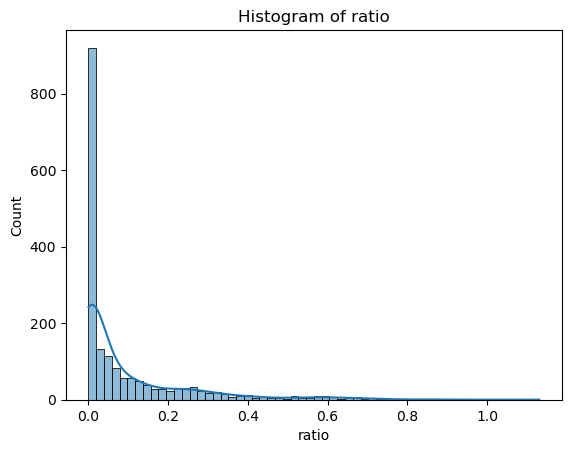

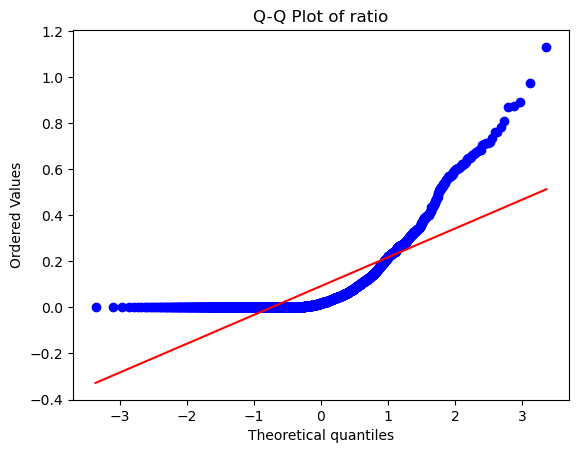

In [347]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# 绘制直方图
sns.histplot(summ['ratio'], kde=True)
plt.title('Histogram of ratio')
plt.show()

# 绘制 Q-Q 图
stats.probplot(summ['ratio'], dist="norm", plot=plt)
plt.title('Q-Q Plot of ratio')
plt.show()

old code

In [55]:
amount_by_code_year_country = result_df.groupby(['Stkcd', 'year', 'Country_Name'])['Export_Amount'].sum().reset_index()
us_export_data = amount_by_code_year_country[amount_by_code_year_country['Country_Name'] == '美国']
company_counts = us_export_data.groupby('Stkcd')['year'].nunique()

# 筛选出至少有2年记录的公司代码
valid_companies = company_counts[company_counts >= 2].index

# 过滤原始数据，保留这些公司代码的数据
us_export_data = us_export_data[us_export_data['Stkcd'].isin(valid_companies)]



In [56]:
us_export_data

,Stkcd,year,Country_Name,Export_Amount
9,000009,2014,美国,422604.0
22,000009,2015,美国,2839189.0
68,000009,2016,美国,6221502.0
159,000012,2014,美国,1053200.0
238,000012,2015,美国,1130745.0
...,...,...,...,...
128379,603996,2015,美国,987162.0
128434,603996,2016,美国,111016037.0
128463,603997,2014,美国,443975.0
128477,603997,2015,美国,590145.0


In [60]:
income_columns = {"Stkcd": "Stkcd","Accper": "year", "B001100000": "revenue", "B002000101": "net_profit"}
df_income_file = RAW/'csmar'/'基本信息'/'利润表000222262'/'FS_Comins.csv'
df_income = pd.read_csv(df_income_file, usecols=income_columns.keys(), dtype={'Stkcd': str}).rename(columns=income_columns)
df_income.loc[:, "year"] = pd.to_datetime(df_income["year"]).dt.year
df_income = df_income[(df_income['Stkcd'] >= "000001") & (df_income['Stkcd'] <= "679999")]
df_income

,Stkcd,year,revenue,net_profit
0,000002,2013,1.354188e+11,1.511855e+10
1,000002,2014,1.463880e+11,1.574545e+10
2,000002,2015,1.955491e+11,1.811941e+10
3,000002,2016,2.404772e+11,2.102261e+10
4,000002,2017,2.428971e+11,2.805181e+10
...,...,...,...,...
36264,605598,2022,8.851052e+08,1.567913e+08
36265,605598,2023,1.277448e+09,1.740950e+08
36266,605599,2021,1.040575e+10,3.639528e+08
36267,605599,2022,1.098987e+10,4.601269e+08


In [61]:
us_export_data = us_export_data.copy()
# 定义年份对应的平均汇率
exchange_rates = {2014: 6.128333, 2015: 6.205000, 2016: 6.614167}

# 将出口数据中年份对应的汇率映射并计算出口金额（RMB）
us_export_data['Exchange_Rate'] = us_export_data['year'].map(exchange_rates)
us_export_data['Export_Amount_RMB'] = us_export_data['Export_Amount'] * us_export_data['Exchange_Rate']

# 合并数据
export_us_revenue = pd.merge(
    us_export_data[['Stkcd', 'year', 'Export_Amount_RMB']],
    df_income[['Stkcd', 'year', 'revenue']],
    on=['Stkcd', 'year'],
    how='inner'
)

# 计算出口到美国的比例
export_us_revenue['Export_To_Revenue_Ratio'] = export_us_revenue['Export_Amount_RMB'] / export_us_revenue['revenue']

export_us_revenue


,Stkcd,year,Export_Amount_RMB,revenue,Export_To_Revenue_Ratio
0,000009,2014,2.589858e+06,4.311477e+09,0.000601
1,000009,2015,1.761717e+07,4.894876e+09,0.003599
2,000009,2016,4.115005e+07,6.449201e+09,0.006381
3,000012,2014,6.454360e+06,7.044503e+09,0.000916
4,000012,2015,7.016273e+06,7.430889e+09,0.000944
...,...,...,...,...,...
2562,603996,2015,6.125340e+06,3.463163e+09,0.001769
2563,603996,2016,7.342786e+08,4.188478e+09,0.175309
2564,603997,2014,2.720827e+06,1.017917e+09,0.002673
2565,603997,2015,3.661850e+06,1.048068e+09,0.003494


In [64]:
export_us_revenue = export_us_revenue[export_us_revenue['Stkcd'] != '000088']
export_us_revenue = export_us_revenue[export_us_revenue['Stkcd'] != '000595']
export_us_revenue.describe(include='all').transpose()


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Stkcd,2561,955,000009,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,2561.0,3.0,2016.0,931.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Export_Amount_RMB,2561.0,NaN,NaN,NaN,154633618.782658,575442476.218274,189.978323,2417888.116854,18725368.1937,96513860.64,12902974975.825851
revenue,2561.0,NaN,NaN,NaN,14364102249.240198,99188212420.808792,59031657.27,1005528094.85,2285243577.06,6169688792.53,2825914000000.0
Export_To_Revenue_Ratio,2561.0,NaN,NaN,NaN,0.039166,0.077362,0.0,0.000915,0.007315,0.038686,0.709305


In [65]:
export_us_revenue.nlargest(10, 'Export_To_Revenue_Ratio')

,Stkcd,year,Export_Amount_RMB,revenue,Export_To_Revenue_Ratio
894,002444,2015,2.253098e+09,3.176485e+09,0.709305
893,002444,2014,1.988035e+09,2.866068e+09,0.693646
895,002444,2016,2.453603e+09,3.603323e+09,0.680928
648,002239,2014,3.016142e+08,4.500020e+08,0.670251
1504,300317,2014,3.665434e+08,6.801460e+08,0.538919
2289,600962,2014,4.646861e+08,8.776052e+08,0.529493
811,002382,2016,6.724289e+08,1.288771e+09,0.521760
2534,603703,2015,1.827364e+08,3.603401e+08,0.507122
1098,002615,2016,6.656532e+08,1.341538e+09,0.496187
2291,600962,2016,4.674115e+08,9.640556e+08,0.484839
